![Imgur](https://i.imgur.com/7FdddzP.jpg)
# **Minería de datos**
## **Semana 5: Visualización de datos**

###Tarea 5 - Herramientas de visualización de datos

---
## **Contexto y objetivo de la tarea**

En esta actividad, el estudiante aplicará los fundamentos de la visualización de datos y el análisis exploratorio para presentar la primera fase de su proyecto. El objetivo es comprender el estado inicial de los datos, identificar patrones preliminares y comunicar hallazgos iniciales mediante representaciones gráficas.



---

---
## **Introducción**

En este cuaderno se analiza un conjunto de datos de transacciones bancarias con el objetivo de explorar el comportamiento de variables como el monto de las transacciones y el tipo de cuenta. A través de estadísticas descriptivas y diferentes técnicas de visualización, se identificarán patrones, distribuciones, valores atípicos y posibles diferencias entre los distintos tipos de cuentas.

---

# **Configuración del entorno**

Ejecutar esta celda para importar todas las librerías necesarias.

In [ ]:
# ============================================================
# Configuración del entorno de trabajo
# ============================================================
# Importar las librerías necesarias para el análisis exploratorio
# y la visualización de datos de transacciones bancarias.

# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Configuración de estilo de las gráficas
# ============================================================

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("Set2")

# Tamaño predeterminado de las figuras
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Librerías cargadas correctamente.")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")

Librerías cargadas correctamente.
Pandas      : 2.2.2
Matplotlib  : 3.10.0
Seaborn     : 0.13.2


---
# **Sección 1: Carga de datos de ejemplo**

Usaremos 1 datasets para ilustrar todas las gráficas:

In [ ]:
# ============================================================
# Sección 1: Carga del conjunto de datos desde GitHub
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/uea-jose/MineriadeDatos/Semana5/table-data2.csv"

df = pd.read_csv(url)

print("\n======================================")
print(" DATASET CARGADO CORRECTAMENTE")
print("======================================")

print("\nPrimeras 5 filas:")
display(df.head())

print("\nDimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nColumnas disponibles:")
print(df.columns.tolist())


 DATASET CARGADO CORRECTAMENTE

Primeras 5 filas:


,timestamp,No.Comrpobante,CuentataOrigen,CuentataDestino,Motivo,Monto,CodigoRespuesta,Mensaje,TipoCuentaOrigen,TipoCuentaDestino,CedulaOrigen,CedulaDestino,Saldo
0,"24/6/2026, 4:23:36 p.m.",139552287.0,8281397800,8522707300,recarga,30.00,0.0,TRANSACCIÓN EXITOSA,CuentaAhorro,CUENTA DE AHORROS,0604372599,1003073366,124.96
1,"25/6/2026, 9:38:59 a.m.",140180407.0,8696444500,8785414500,Pago,13.00,0.0,TRANSACCIÓN EXITOSA,CuentaAhorro,CUENTA AHORRO LISTO,0805244159,0805244159,0.54
2,"25/6/2026, 2:32:52 p.m.",140612610.0,8764172400,8361854400,Transf Terceros,10.00,0.0,TRANSACCIÓN EXITOSA,CuentaAhorro,CUENTA DE AHORROS,1601031907,0504115569,376.49
3,"21/6/2026, 4:10:04 p.m.",135911743.0,8684961400,8758536200,Transf Terceros,10.00,0.0,TRANSACCIÓN EXITOSA,CuentaAhorro,CUENTA DE AHORROS,2350801862,0702666413,280.27
4,"21/6/2026, 9:49:24 a.m.",135629708.0,8694194400,8176818100,Transf Terceros,4.00,0.0,TRANSACCIÓN EXITOSA,AhorroListo,CUENTA DE AHORROS,1717133647,1717133647,0.44



Dimensiones del dataset:
Filas: 35683
Columnas: 13

Columnas disponibles:
['timestamp', 'No.Comrpobante', 'CuentataOrigen', 'CuentataDestino', 'Motivo', 'Monto', 'CodigoRespuesta', 'Mensaje', 'TipoCuentaOrigen', 'TipoCuentaDestino', 'CedulaOrigen', 'CedulaDestino', 'Saldo']


Definimos las columnas numéricas de Iris para usarlas a lo largo del cuaderno:

In [ ]:
# ============================================================
# Identificación automática de variables numéricas
# ============================================================

# Detectar todas las columnas numéricas del dataset
num_cols = df.select_dtypes(include="number").columns.tolist()

print("=== VARIABLES NUMÉRICAS DETECTADAS ===")
print(num_cols)

print(f"\nSe encontraron {len(num_cols)} variables numéricas.")

=== VARIABLES NUMÉRICAS DETECTADAS ===
['No.Comrpobante', 'CuentataOrigen', 'CuentataDestino', 'CodigoRespuesta']

Se encontraron 4 variables numéricas.


---
## **Sección 1.1:  Características iniciales del dataset.**



In [ ]:
# ============================================================
# INFORMACIÓN ESTRUCTURAL DEL DATASET
# ============================================================

print("=" * 70)
print("INFORMACIÓN ESTRUCTURAL DEL CONJUNTO DE DATOS")
print("=" * 70)

# Información general
df.info()

# Dimensiones
print("\n")
print("=" * 70)
print("DIMENSIONES DEL DATASET")
print("=" * 70)
print(f"Filas    : {df.shape[0]}")
print(f"Columnas : {df.shape[1]}")

# Tipos de datos
print("\n")
print("=" * 70)
print("TIPOS DE DATOS")
print("=" * 70)
display(df.dtypes.to_frame(name="Tipo de dato"))

INFORMACIÓN ESTRUCTURAL DEL CONJUNTO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35683 entries, 0 to 35682
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          35683 non-null  object 
 1   No.Comrpobante     35656 non-null  float64
 2   CuentataOrigen     35683 non-null  int64  
 3   CuentataDestino    35683 non-null  int64  
 4   Motivo             35683 non-null  object 
 5   Monto              35683 non-null  object 
 6   CodigoRespuesta    35672 non-null  float64
 7   Mensaje            35672 non-null  object 
 8   TipoCuentaOrigen   33863 non-null  object 
 9   TipoCuentaDestino  35574 non-null  object 
 10  CedulaOrigen       35683 non-null  object 
 11  CedulaDestino      35679 non-null  object 
 12  Saldo              35672 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 3.5+ MB


DIMENSIONES DEL DATASET
Filas    : 35683
Columnas : 13


TIPO

,Tipo de dato
timestamp,object
No.Comrpobante,float64
CuentataOrigen,int64
CuentataDestino,int64
Motivo,object
Monto,object
CodigoRespuesta,float64
Mensaje,object
TipoCuentaOrigen,object
TipoCuentaDestino,object


## **2.1 Medidas de tendencia central**

| Medida | Definición | Fórmula |
|--------|------------|--------|
| **Media** ($\bar{x}$) | Promedio aritmético | $\frac{1}{n}\sum_{i=1}^{n} x_i$ |
| **Mediana** | Valor central (50° percentil) | — |
| **Moda** | Valor más frecuente | — |

**¿Por qué son importantes?**  
La media se ve afectada por valores atípicos; la mediana es robusta. Si media $\neq$ mediana, la distribución es asimétrica.

In [ ]:
# ============================================================
# Preparación del dataset
# ============================================================

# Variables numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()

# Variables categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:")
print(num_cols)

print("\nVariables categóricas:")
print(cat_cols)

Variables numéricas:
['No.Comrpobante', 'CuentataOrigen', 'CuentataDestino', 'CodigoRespuesta']

Variables categóricas:
['timestamp', 'Motivo', 'Monto', 'Mensaje', 'TipoCuentaOrigen', 'TipoCuentaDestino', 'CedulaOrigen', 'CedulaDestino', 'Saldo']


## **2.2 Medidas de dispersión**

Indican cuán **separados** están los datos entre sí.

| Medida | Definición | Interpretación |
|--------|------------|----------------|
| **Rango** | Máx − Mín | Dispersión total de los datos |
| **Varianza** ($\sigma^2$) | $\frac{1}{n}\sum (x_i - \bar{x})^2$ | Dispersión al cuadrado (unidades$^2$) |
| **Desviación estándar** ($\sigma$) | $\sqrt{\sigma^2}$ | Dispersión en las unidades originales |
| **IQR (RIC)** | Q3 − Q1 | Dispersión del 50% central de los datos |

**Regla empírica (distribución normal):** ~68% datos en $\bar{x} \pm \sigma$, ~95% en $\bar{x} \pm 2\sigma$.

In [ ]:
# ============================================================
# MEDIDAS DE DISPERSIÓN
# ============================================================

# Si num_cols no existe, lo crea automáticamente
if "num_cols" not in globals():
    num_cols = df.select_dtypes(include="number").columns.tolist()

print("=" * 80)
print("MEDIDAS DE DISPERSIÓN")
print("=" * 80)

for col in num_cols:

    rango = df[col].max() - df[col].min()
    varianza = df[col].var()
    desviacion = df[col].std()
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)

    print(f"\nVariable: {col}")
    print(f"   Rango                : {rango:,.2f}")
    print(f"   Varianza             : {varianza:,.2f}")
    print(f"   Desviación estándar  : {desviacion:,.2f}")
    print(f"   IQR (RIC)            : {iqr:,.2f}")

MEDIDAS DE DISPERSIÓN

Variable: No.Comrpobante
   Rango                : 835,506,548.00
   Varianza             : 1,049,298,628,318,805.25
   Desviación estándar  : 32,392,879.28
   IQR (RIC)            : 4,156,508.75

Variable: CuentataOrigen
   Rango                : 8,720,286,600.00
   Varianza             : 78,360,850,064,739,568.00
   Desviación estándar  : 279,930,080.67
   IQR (RIC)            : 503,083,650.00

Variable: CuentataDestino
   Rango                : 87,622,999,555.00
   Varianza             : 2,895,786,467,957,943,808.00
   Desviación estándar  : 1,701,701,051.29
   IQR (RIC)            : 514,518,300.00

Variable: CodigoRespuesta
   Rango                : 9,997.00
   Varianza             : 214,667.09
   Desviación estándar  : 463.32
   IQR (RIC)            : 0.00


## **2.3 Asimetría (Skewness) y Curtosis**

**Asimetría** → forma de la distribución respecto al centro:
- $= 0$: simétrica (campana de Gauss)
- $> 0$: sesgo positivo (cola larga a la derecha; media $>$ mediana)
- $< 0$: sesgo negativo (cola larga a la izquierda; media $<$ mediana)

**Curtosis** → qué tan "pesadas" son las colas:
- $\approx 0$: mesocúrtica (como la normal)
- $> 0$: leptocúrtica (colas pesadas, pico agudo — más outliers)
- $< 0$: platicúrtica (colas ligeras, forma aplanada)

In [ ]:
# ============================================================
# ASIMETRÍA Y CURTOSIS
# ============================================================

# Si num_cols no existe, lo crea automáticamente
if "num_cols" not in globals():
    num_cols = df.select_dtypes(include="number").columns.tolist()

print("=" * 80)
print("ASIMETRÍA Y CURTOSIS")
print("=" * 80)

for col in num_cols:

    skew = df[col].skew()
    kurt = df[col].kurtosis()   # Exceso de curtosis

    print(f"\nVariable: {col}")
    print(f"   Asimetría : {skew:+.3f}")
    print(f"   Curtosis  : {kurt:+.3f}")

    # Interpretación automática
    if skew > 0.5:
        print("   Interpretación: Sesgo positivo.")
    elif skew < -0.5:
        print("   Interpretación: Sesgo negativo.")
    else:
        print("   Interpretación: Distribución aproximadamente simétrica.")

    if kurt > 0:
        print("   Curtosis: Presencia de valores extremos (leptocúrtica).")
    elif kurt < 0:
        print("   Curtosis: Distribución más plana (platicúrtica).")
    else:
        print("   Curtosis: Similar a una distribución normal.")

ASIMETRÍA Y CURTOSIS

Variable: No.Comrpobante
   Asimetría : +16.122
   Curtosis  : +366.185
   Interpretación: Sesgo positivo.
   Curtosis: Presencia de valores extremos (leptocúrtica).

Variable: CuentataOrigen
   Asimetría : -2.762
   Curtosis  : +66.985
   Interpretación: Sesgo negativo.
   Curtosis: Presencia de valores extremos (leptocúrtica).

Variable: CuentataDestino
   Asimetría : +43.924
   Curtosis  : +1985.475
   Interpretación: Sesgo positivo.
   Curtosis: Presencia de valores extremos (leptocúrtica).

Variable: CodigoRespuesta
   Asimetría : +17.797
   Curtosis  : +333.276
   Interpretación: Sesgo positivo.
   Curtosis: Presencia de valores extremos (leptocúrtica).


In [ ]:
# ============================================================
# RESUMEN ESTADÍSTICO DESCRIPTIVO
# ============================================================

# Si num_cols no existe, lo crea automáticamente
if "num_cols" not in globals():
    num_cols = df.select_dtypes(include="number").columns.tolist()

print("=" * 80)
print("RESUMEN ESTADÍSTICO DESCRIPTIVO")
print("=" * 80)

display(df[num_cols].describe().T)

RESUMEN ESTADÍSTICO DESCRIPTIVO


,count,mean,std,min,25%,50%,75%,max
No.Comrpobante,35656.0,1.391309e+08,3.239288e+07,0.0,1.373263e+08,1.393649e+08,1.414828e+08,8.355065e+08
CuentataOrigen,35683.0,8.496692e+09,2.799301e+08,86593000.0,8.234670e+09,8.608004e+09,8.737754e+09,8.806880e+09
CuentataDestino,35683.0,8.491518e+09,1.701701e+09,86656445.0,8.182956e+09,8.562169e+09,8.697474e+09,8.770966e+10
CodigoRespuesta,35672.0,3.396367e+01,4.633218e+02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,9.997000e+03


---
# **GRÁFICA 1: HISTOGRAMA**

## **¿Para qué sirve?**
El histograma **divide los datos en intervalos (bins)** y cuenta cuántas observaciones caen en cada uno. Es la herramienta fundamental para **visualizar la forma de una distribución**: simétrica, sesgada, multimodal (varios picos), presencia de valores atípicos.

## **Parámetros clave**

### Con matplotlib (`plt.hist()`)

| Parámetro | Qué hace | Ejemplo |
|-----------|----------|---------|
| `x` | Los datos (array/Series) | `iris['largo_petalo']` |
| `bins` | Número de intervalos (o lista de bordes). Más bins = más detalle, menos suavidad | `bins=15` |
| `color` | Color de relleno | `color='steelblue'` |
| `edgecolor` | Color del borde de cada barra | `edgecolor='white'` |
| `alpha` | Transparencia (0=invisible, 1=sólido) | `alpha=0.8` |
| `density` | Si `True`, normaliza el área a 1 (como densidad) | `density=True` |
| `histtype` | Tipo: `'bar'`, `'step'`, `'stepfilled'` | `histtype='step'` |

### Con seaborn (`sns.histplot()`)
| Parámetro | Qué hace |
|-----------|----------|
| `kde=True` | Superpone una curva de densidad suavizada |
| `element='step'` | Dibuja como escalones en vez de barras |
| `multiple='stack'` | Apila grupos en lugar de superponerlos |

## **Ejemplo aplicado: distribución de los montos de las transacciones bancarias**

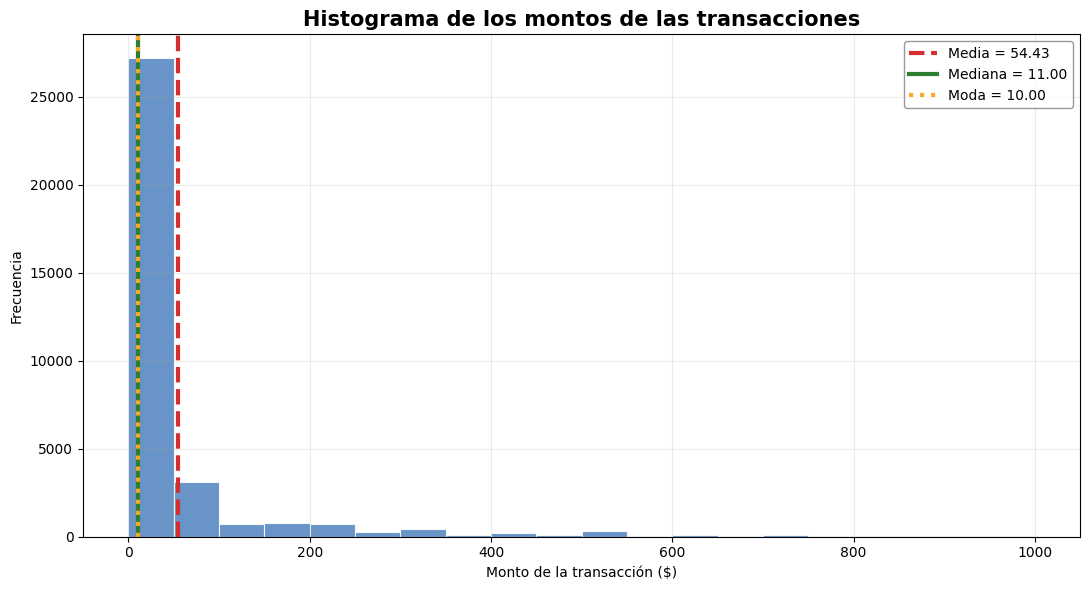

MEDIDAS DE TENDENCIA CENTRAL
Media   : 54.43
Mediana : 11.00
Moda(s) : [10.0]

Interpretación:
- El histograma muestra la distribución de los montos de las transacciones.
- La línea roja representa la media (promedio).
- La línea verde representa la mediana (valor central).
- La línea dorada representa la moda (valor más frecuente).
- La comparación entre estas medidas permite identificar posibles asimetrías en la distribución.


In [ ]:
# ============================================================
# GRÁFICA 1: HISTOGRAMA DE MONTOS
# ============================================================

# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Cargar dataset desde GitHub
# ============================================================

url = "https://raw.githubusercontent.com/uea-jose/MineriadeDatos/Semana5/table-data2.csv"

df = pd.read_csv(url)

# ============================================================
# Variable numérica a analizar
# ============================================================

columna = "Monto"

# Convertir la columna a tipo numérico
df[columna] = pd.to_numeric(df[columna], errors="coerce")

# Eliminar valores nulos
datos = df[columna].dropna()

# ============================================================
# Medidas de tendencia central
# ============================================================

media = datos.mean()
mediana = datos.median()
modas = datos.mode()

# ============================================================
# Crear gráfico
# ============================================================

plt.figure(figsize=(11,6))

plt.hist(
    datos,
    bins=20,
    color="#4F81BD",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85
)

# ============================================================
# Media
# ============================================================

plt.axvline(
    media,
    color="#D32F2F",
    linestyle="--",
    linewidth=3,
    label=f"Media = {media:.2f}"
)

# ============================================================
# Mediana
# ============================================================

plt.axvline(
    mediana,
    color="#2E7D32",
    linestyle="-",
    linewidth=3,
    label=f"Mediana = {mediana:.2f}"
)

# ============================================================
# Moda
# ============================================================

for i, moda in enumerate(modas):

    plt.axvline(
        moda,
        color="#F9A825",
        linestyle=":",
        linewidth=3,
        label=f"Moda = {moda:.2f}" if i == 0 else ""
    )

# ============================================================
# Personalización
# ============================================================

plt.title(
    "Histograma de los montos de las transacciones",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Monto de la transacción ($)")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.25)

plt.legend(
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="gray"
)

plt.tight_layout()
plt.show()

# ============================================================
# Resultados
# ============================================================

print("="*70)
print("MEDIDAS DE TENDENCIA CENTRAL")
print("="*70)

print(f"Media   : {media:,.2f}")
print(f"Mediana : {mediana:,.2f}")
print(f"Moda(s) : {list(modas.round(2))}")

print("\nInterpretación:")
print("- El histograma muestra la distribución de los montos de las transacciones.")
print("- La línea roja representa la media (promedio).")
print("- La línea verde representa la mediana (valor central).")
print("- La línea dorada representa la moda (valor más frecuente).")
print("- La comparación entre estas medidas permite identificar posibles asimetrías en la distribución.")

## **Variante: Histograma + curva de densidad (KDE) de los montos**

La curva KDE suaviza la distribución de los montos, facilitando identificar la concentración de las transacciones y la forma general de la distribución.

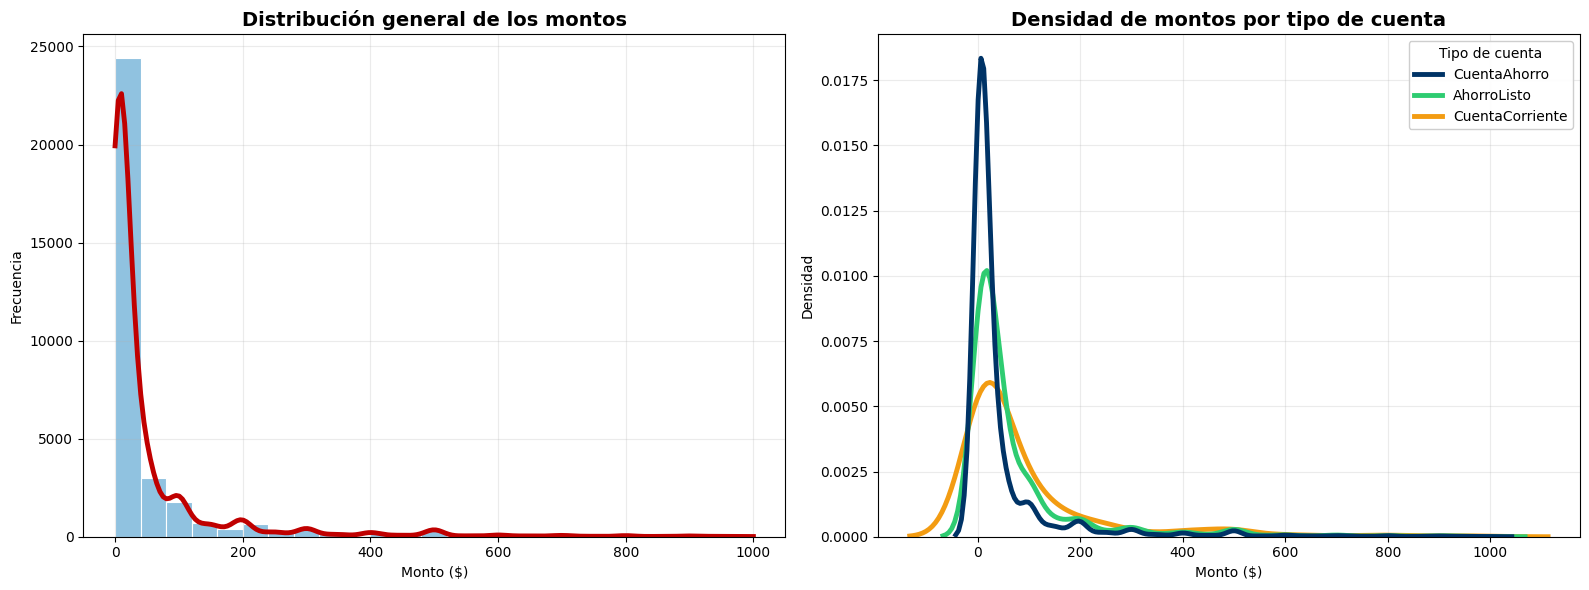

Interpretación:
- El primer gráfico muestra la distribución general de los montos de las transacciones.
- La línea roja representa la tendencia suavizada KDE.
- El segundo gráfico compara las distribuciones de montos por tipo de cuenta.
- Al usar líneas KDE, los tipos de cuenta se distinguen mejor aunque tengan cantidades diferentes de registros.
- Si una curva se concentra a la izquierda, indica mayor frecuencia de transacciones de montos bajos.


In [ ]:
# ============================================================
# HISTOGRAMA + KDE GENERAL Y KDE POR TIPO DE CUENTA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir Monto a numérico
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

# Eliminar registros incompletos y montos negativos o nulos
df_hist = df.dropna(subset=["Monto", "TipoCuentaOrigen"])
df_hist = df_hist[df_hist["Monto"] > 0]

# Paleta de alto contraste
palette_banco = {
    "CuentaAhorro": "#003366",
    "AhorroListo": "#2ECC71",
    "CuentaCorriente": "#F39C12"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1
sns.histplot(
    data=df_hist,
    x="Monto",
    bins=25,
    kde=True,
    color="#6BAED6",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.75,
    ax=axes[0]
)

if len(axes[0].lines) > 0:
    axes[0].lines[-1].set_color("#C00000")
    axes[0].lines[-1].set_linewidth(3.5)

axes[0].set_title("Distribución general de los montos", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Monto ($)")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.25)

# GRÁFICO 2
sns.kdeplot(
    data=df_hist,
    x="Monto",
    hue="TipoCuentaOrigen",
    fill=False,
    common_norm=False,
    linewidth=3.5,
    palette=palette_banco,
    ax=axes[1]
)

axes[1].set_title("Densidad de montos por tipo de cuenta", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Monto ($)")
axes[1].set_ylabel("Densidad")
axes[1].grid(alpha=0.25)

legend = axes[1].get_legend()
if legend:
    legend.set_title("Tipo de cuenta")
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.95)

plt.tight_layout()
plt.show()

print("Interpretación:")
print("- El primer gráfico muestra la distribución general de los montos de las transacciones.")
print("- La línea roja representa la tendencia suavizada KDE.")
print("- El segundo gráfico compara las distribuciones de montos por tipo de cuenta.")
print("- Al usar líneas KDE, los tipos de cuenta se distinguen mejor aunque tengan cantidades diferentes de registros.")
print("- Si una curva se concentra a la izquierda, indica mayor frecuencia de transacciones de montos bajos.")

---
# **GRÁFICA 2: GRÁFICO DE DENSIDAD (KDE)**

## **¿Para qué sirve?**
El KDE (Kernel Density Estimation) estima la **función de densidad de probabilidad** de forma suavizada, sin necesidad de bins. Es ideal para **comparar distribuciones** entre grupos en una misma gráfica.

## **Parámetros clave**

| Parámetro | Qué hace |
|-----------|----------|
| `data` | DataFrame con los datos |
| `x` | Columna numérica a graficar |
| `hue` | Columna categórica para separar grupos |
| `fill=True` | Rellena el área bajo la curva con color |
| `alpha` | Transparencia (0-1) |
| `linewidth` | Grosor de la línea |
| `bw_method` | Ancho de banda (`'scott'`, `'silverman'`, o número). Controla cuán suave es la curva |
| `clip` | Limitar el rango del eje X |

## **Ejemplo aplicado: comparar la distribución de los montos entre los diferentes tipos de cuentas**

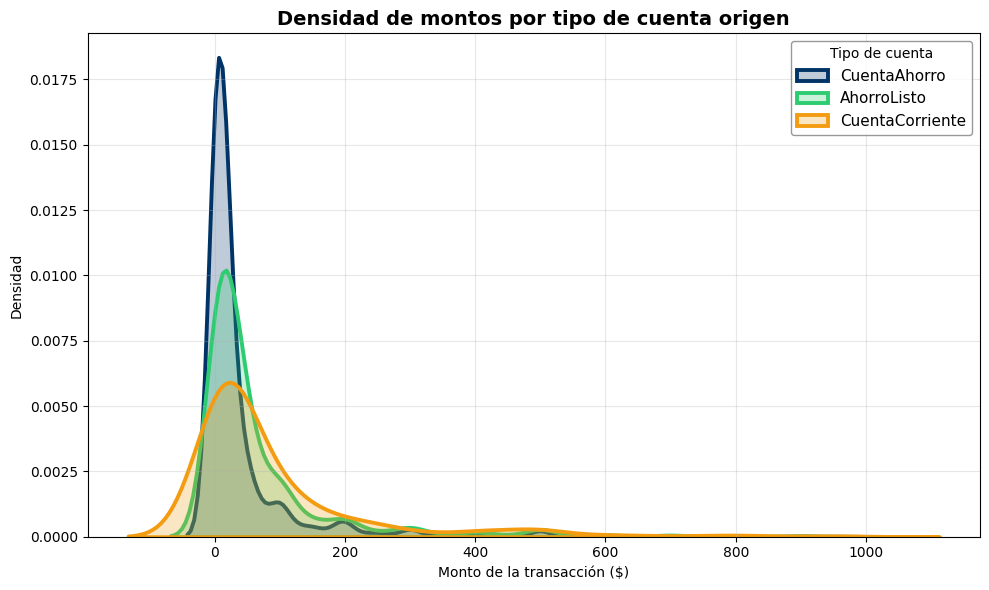

Interpretación:
- Cada curva representa la distribución de los montos para un tipo de cuenta origen.
- Las curvas más altas indican mayor concentración de transacciones en determinados rangos de monto.
- Si una curva se extiende hacia la derecha, significa que existen transacciones de mayor valor.
- Este gráfico permite comparar el comportamiento de los montos entre CuentaAhorro, AhorroListo y CuentaCorriente.


In [ ]:
# ============================================================
# GRÁFICA 2: KDE DE MONTOS POR TIPO DE CUENTA
# ============================================================

# Convertir la variable Monto a numérica
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

# Eliminar registros incompletos y montos no válidos
df_kde = df.dropna(subset=["Monto", "TipoCuentaOrigen"])
df_kde = df_kde[df_kde["Monto"] > 0]

# Paleta de colores para cada tipo de cuenta
palette_banco = {
    "CuentaAhorro": "#003366",
    "AhorroListo": "#2ECC71",
    "CuentaCorriente": "#F39C12"
}

plt.figure(figsize=(10, 6))

for tipo_cuenta in df_kde["TipoCuentaOrigen"].unique():

    subset = df_kde[df_kde["TipoCuentaOrigen"] == tipo_cuenta]

    sns.kdeplot(
        data=subset,
        x="Monto",
        label=tipo_cuenta,
        fill=True,
        alpha=0.25,
        linewidth=2.8,
        color=palette_banco.get(tipo_cuenta, "#7F8C8D")
    )

plt.title(
    "Densidad de montos por tipo de cuenta origen",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Monto de la transacción ($)")
plt.ylabel("Densidad")
plt.grid(alpha=0.30)

plt.legend(
    title="Tipo de cuenta",
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="gray"
)

plt.tight_layout()
plt.show()

print("Interpretación:")
print("- Cada curva representa la distribución de los montos para un tipo de cuenta origen.")
print("- Las curvas más altas indican mayor concentración de transacciones en determinados rangos de monto.")
print("- Si una curva se extiende hacia la derecha, significa que existen transacciones de mayor valor.")
print("- Este gráfico permite comparar el comportamiento de los montos entre CuentaAhorro, AhorroListo y CuentaCorriente.")

---
# **GRÁFICA 3: DIAGRAMA DE CAJA Y BIGOTES (BOX PLOT)**

## **¿Para qué sirve?**
Resume la distribución mediante **5 números**: mínimo, Q1, mediana, Q3, máximo (sin contar outliers). Es la mejor gráfica para **detectar valores atípicos (outliers)** y comparar distribuciones entre grupos.

**Estructura de un boxplot:**
```
              o   <- outlier (valor > Q3 + 1.5×IQR)
    ─────     <- bigote superior (máximo dentro de 1.5×IQR)
  ┌───────┐
  │  Q3   │   <- tercer cuartil (75%)
  │ Med   │   <- mediana (50%)
  │  Q1   │   <- primer cuartil (25%)
  └───────┘
    ─────     <- bigote inferior (mínimo dentro de 1.5×IQR)
```

## **Parámetros clave**

| Parámetro | Qué hace |
|-----------|----------|
| `x` | Columna categórica (eje X) |
| `y` | Columna numérica (eje Y) |
| `hue` | Segunda categoría para subagrupar |
| `notch` | Si `True`, hace una muesca en la mediana (intervalo de confianza) |
| `vert` | Si `False`, el boxplot es horizontal |
| `whis` | Proporción del IQR para bigotes (default 1.5) |
| `showfliers` | Si `False`, oculta los outliers |
| `palette` | Paleta de colores |

## **Ejemplo aplicado: comparar la distribución de los montos de las transacciones según el tipo de cuenta origen.*

/tmp/ipykernel_2297/2107867766.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2297/2107867766.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


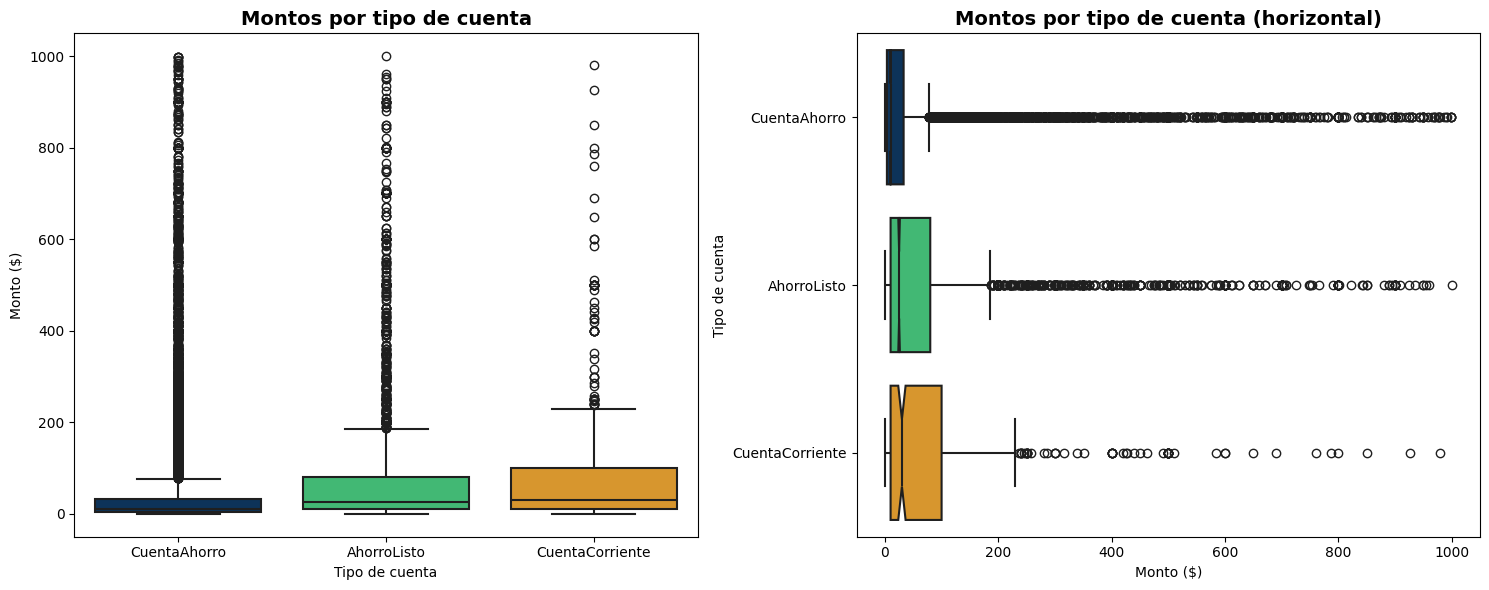

Interpretación:
- La línea central de cada caja representa la mediana de los montos.
- La altura de cada caja refleja la dispersión del 50% central de las transacciones (IQR).
- Los puntos fuera de los bigotes corresponden a posibles valores atípicos (outliers).
- El gráfico permite comparar la variabilidad y la distribución de los montos entre los diferentes tipos de cuenta.


In [ ]:
# ============================================================
# GRÁFICA 3: DIAGRAMA DE CAJA Y BIGOTES (BOXPLOT)
# ============================================================

# Convertir Monto a numérico
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

# Eliminar registros incompletos
df_box = df.dropna(subset=["Monto", "TipoCuentaOrigen"])

# Orden de los tipos de cuenta (si existen)
orden_cuentas = [
    "CuentaAhorro",
    "AhorroListo",
    "CuentaCorriente"
]

# Mantener solo las categorías presentes en el dataset
orden_cuentas = [
    cuenta for cuenta in orden_cuentas
    if cuenta in df_box["TipoCuentaOrigen"].unique()
]

# Colores corporativos
palette_banco = {
    "CuentaAhorro": "#003366",       # Azul marino
    "AhorroListo": "#2ECC71",        # Verde
    "CuentaCorriente": "#F39C12"     # Dorado
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================================
# Boxplot vertical
# ============================================================

sns.boxplot(
    data=df_box,
    x="TipoCuentaOrigen",
    y="Monto",
    order=orden_cuentas,
    palette=palette_banco,
    linewidth=1.5,
    ax=axes[0]
)

axes[0].set_title(
    "Montos por tipo de cuenta",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Tipo de cuenta")
axes[0].set_ylabel("Monto ($)")

# ============================================================
# Boxplot horizontal con muesca
# ============================================================

sns.boxplot(
    data=df_box,
    y="TipoCuentaOrigen",
    x="Monto",
    orient="h",
    order=orden_cuentas,
    palette=palette_banco,
    notch=True,
    linewidth=1.5,
    ax=axes[1]
)

axes[1].set_title(
    "Montos por tipo de cuenta (horizontal)",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Monto ($)")
axes[1].set_ylabel("Tipo de cuenta")

plt.tight_layout()
plt.show()

# ============================================================
# Interpretación
# ============================================================

print("Interpretación:")
print("- La línea central de cada caja representa la mediana de los montos.")
print("- La altura de cada caja refleja la dispersión del 50% central de las transacciones (IQR).")
print("- Los puntos fuera de los bigotes corresponden a posibles valores atípicos (outliers).")
print("- El gráfico permite comparar la variabilidad y la distribución de los montos entre los diferentes tipos de cuenta.")

---
# **GRÁFICA 4: DIAGRAMA DE VIOLÍN (VIOLIN PLOT)**

## **¿Para qué sirve?**
Es una **combinación de boxplot y KDE**. Muestra la distribución completa (densidad) y además los cuartiles y la mediana. Es mejor que el boxplot cuando se quiere ver la **forma de la distribución**.

## **Parámetros clave**

| Parámetro | Qué hace |
|-----------|----------|
| `inner` | Qué mostrar dentro: `'box'` (caja), `'quartile'` (cuartiles), `'point'` (puntos), `'stick'` (líneas) |
| `split` | Si `True`, divide el violín a la mitad para comparar 2 grupos (con `hue`) |
| `scale` | Cómo escalar: `'area'`, `'count'`, `'width'` |
| `bw` | Ancho de banda (como en KDE) |

## **Ejemplo aplicado: comparar la distribución de los montos según el tipo de cuenta origen**

/tmp/ipykernel_2297/637808463.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2297/637808463.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


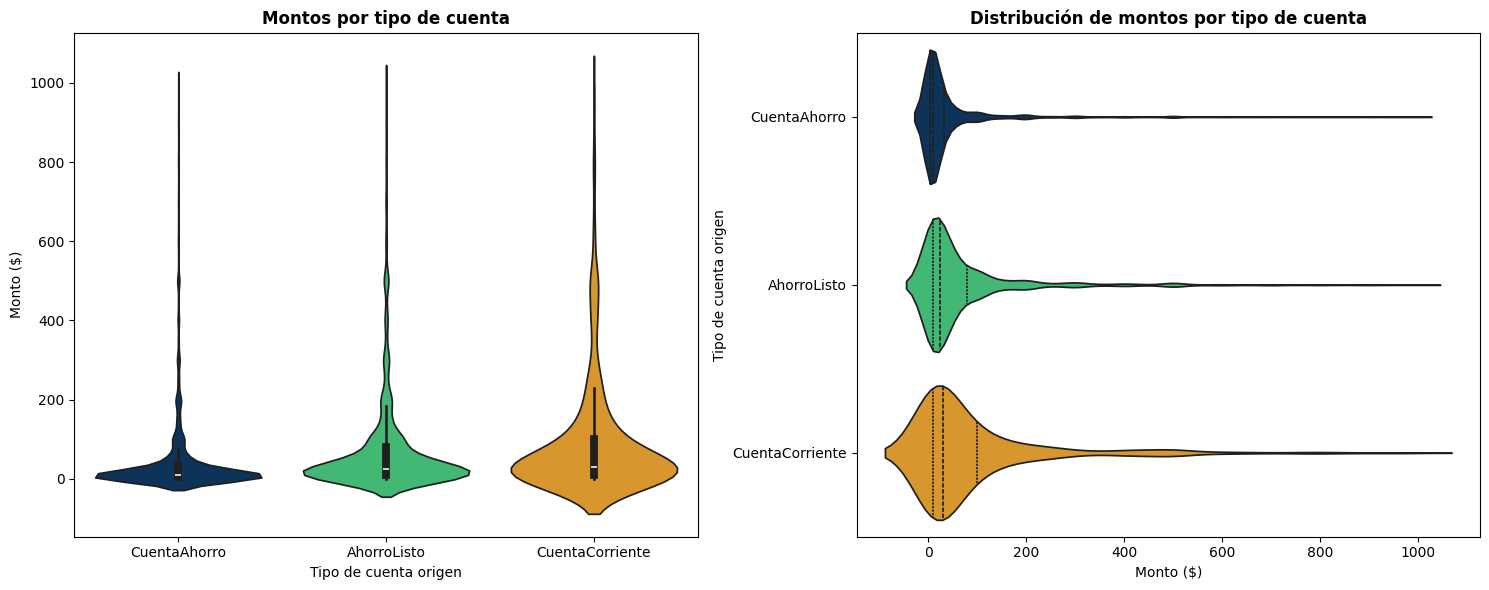

Interpretación:
- Cada violín representa la distribución de los montos para un tipo de cuenta.
- La anchura del violín indica mayor concentración de transacciones.
- La caja interna y los cuartiles muestran mediana y dispersión.
- Permite comparar la forma de la distribución entre los tipos de cuenta.


In [ ]:
# ============================================================
# GRÁFICA 4: DIAGRAMA DE VIOLÍN
# ============================================================

# Verificar que el dataset ya esté cargado
if "df" not in globals():
    raise Exception("Primero ejecuta la celda de carga del dataset para crear el DataFrame df.")

# Convertir Monto a numérico
df["Monto"] = pd.to_numeric(df["Monto"], errors="coerce")

# Eliminar registros incompletos y montos no válidos
df_violin = df.dropna(subset=["Monto", "TipoCuentaOrigen"])
df_violin = df_violin[df_violin["Monto"] > 0]

# Colores corporativos
palette_banco = {
    "CuentaAhorro": "#003366",
    "AhorroListo": "#2ECC71",
    "CuentaCorriente": "#F39C12"
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Violín 1: montos por tipo de cuenta
sns.violinplot(
    data=df_violin,
    x="TipoCuentaOrigen",
    y="Monto",
    palette=palette_banco,
    inner="box",
    ax=axes[0]
)

axes[0].set_title("Montos por tipo de cuenta", fontweight="bold")
axes[0].set_xlabel("Tipo de cuenta origen")
axes[0].set_ylabel("Monto ($)")

# Violín 2: horizontal con cuartiles
sns.violinplot(
    data=df_violin,
    y="TipoCuentaOrigen",
    x="Monto",
    palette=palette_banco,
    inner="quartile",
    ax=axes[1]
)

axes[1].set_title("Distribución de montos por tipo de cuenta", fontweight="bold")
axes[1].set_xlabel("Monto ($)")
axes[1].set_ylabel("Tipo de cuenta origen")

plt.tight_layout()
plt.show()

print("Interpretación:")
print("- Cada violín representa la distribución de los montos para un tipo de cuenta.")
print("- La anchura del violín indica mayor concentración de transacciones.")
print("- La caja interna y los cuartiles muestran mediana y dispersión.")
print("- Permite comparar la forma de la distribución entre los tipos de cuenta.")